In [87]:
# ============================================================
# BACKGROUND FINAL — muon veto CUPID: WBC2 vs WBC3 (alla pari)
# Fotosensore: Hamamatsu H10721-210 (UBA). SiPM tenuto commentato.
# ============================================================
import uproot, numpy as np, matplotlib.pyplot as plt, os, math

DATA_DIR   = "/Users/benussi/Testbeam2026_WC_unified/data"
OUTPUT_DIR = "/Users/benussi/Testbeam2026_WC_unified/Analysis_script_background/output_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- geometrie candidate, ENTRAMBE ALLA PARI (colori distinti) ---
GEO = {
    "WBC2": {"tag": "single_wbc2", "c_mu": "#d62728", "c_g": "#ff7f0e", "ls": "-",  "mk": "o"},
    "WBC3": {"tag": "single_wbc3", "c_mu": "#1f77b4", "c_g": "#9467bd", "ls": "--", "mk": "s"},
    # "single": {"tag": "single", "c_mu": "#7f7f7f", "c_g": "#c7c7c7", "ls": ":", "mk": "^"},  # storico
}
SRC = ["mu_lngs", "gamma"]

# --- digitizzatore ---
DT=0.4; REC=1024; VPP=1000.0; BITS=12; LSB=VPP/2**BITS
TRIG=150.0; NOISE_ADC=2.0
i0=int(140/DT); i1=min(REC-1, int(200/DT)); taxis=np.arange(REC)*DT
e=1.602e-19; R=50.0
TRANS=10**(-(0.15*10.0)/20.0)                 # cavo 10 m RG-58
trtot=math.sqrt(0.6**2+(0.14*10.0)**2); sigT=trtot/2.22

# PMT Hamamatsu H10721-210 (ultra-bialkali, HV integrato)
G=2.0e6; SPE_RES=0.35; TTS=0.3/2.355
amp=-(e*G*R)/(sigT*1e-9*math.sqrt(2*math.pi))*1e3*TRANS   # ampiezza 1 p.e. (mV)
qSPE=abs(amp)*sigT/DT*math.sqrt(2*math.pi)/LSB            # carica 1 p.e. (ADC*samples)

# QE ultra-bialkali H10721-210
_WL=[200,250,300,350,380,400,420,450,500,550,600,650,700]
_QE=[0.20,0.30,0.38,0.42,0.43,0.43,0.42,0.38,0.27,0.14,0.05,0.010,0.00]
def get_qe(wl): return np.interp(wl, _WL, _QE, left=0., right=0.)
def charge(wf): return float(-np.trapezoid(wf[i0:i1])/LSB)

def digitize(t_acc, rng):
    noise = rng.normal(0., NOISE_ADC*LSB, REC)
    if len(t_acc)==0: return noise
    g  = np.maximum(0., rng.normal(1., SPE_RES, len(t_acc)))
    ts = t_acc + TRIG + rng.normal(0., TTS, len(t_acc))
    dt = taxis[:,None] - ts[None,:]
    return amp*(np.exp(-0.5*(dt/sigT)**2) @ g) + noise

# --- SiPM S14160-6075HS: TENUTO per confronto futuro (decommentare) ---
# SIPM = dict(gain=5.0e6, spe_res=0.10, tts=0.15, dcr_hz=2.0e6, p_ct=0.07,
#             tau_r=1.0, tau_f=25.0,
#             wl=[280,300,350,400,450,500,550,600,650,700,800,900],
#             eff=[0.10,0.18,0.32,0.44,0.50,0.46,0.40,0.33,0.27,0.21,0.10,0.04])

_tg = taxis[i0:i1]                       # asse tempi del solo gate (150 campioni)

def _charge_ch(ts, rng):
    """Carica (ADC*samples) di un canale: ts = tempi fotoni accettati (ns)."""
    noise = rng.normal(0., NOISE_ADC*LSB, len(_tg))
    if len(ts) == 0:
        return -np.trapezoid(noise)/LSB
    g  = np.maximum(0., rng.normal(1., SPE_RES, len(ts)))
    tj = ts + TRIG + rng.normal(0., TTS, len(ts))
    dt = _tg[:, None] - tj[None, :]
    wf = amp*(np.exp(-0.5*(dt/sigT)**2) @ g) + noise
    return -np.trapezoid(wf)/LSB

def load_geo(tag, src, rng):
    f = os.path.join(DATA_DIR, f"sim_{tag}_{src}_X0mm_Y0mm_Th0deg.root")
    with uproot.open(f) as fh:
        n_gen = int(fh["Eventi"].num_entries)
        a = fh["Fotoni"].arrays(["EventID","Arrival_Time_ns","PMT_ID","E_Hit_eV"], library="np")
    eid = a["EventID"]; t = a["Arrival_Time_ns"]; pid = a["PMT_ID"]
    # QE una volta sola, vettorizzata
    acc = rng.random(len(eid)) < get_qe(1240.0/a["E_Hit_eV"])
    # raggruppa per EventID senza filtri O(N) ripetuti
    order = np.argsort(eid, kind="stable")
    eid_s, t_s, pid_s, acc_s = eid[order], t[order], pid[order], acc[order]
    uev, starts = np.unique(eid_s, return_index=True)
    bounds = np.append(starts, len(eid_s))
    qa = np.empty(len(uev)); qb = np.empty(len(uev))
    for k in range(len(uev)):
        sl = slice(bounds[k], bounds[k+1])
        p = pid_s[sl]; tt = t_s[sl]; aa = acc_s[sl]
        qa[k] = _charge_ch(tt[(p == 0) & aa], rng)
        qb[k] = _charge_ch(tt[(p == 1) & aa], rng)
    qa /= qSPE; qb /= qSPE                                # carica per canale in PE
    return {"a": qa, "b": qb, "pe": np.maximum(qa, qb),
            "n_gen": n_gen, "n_hits": len(uev)}

rng = np.random.default_rng(11)
RESULTS_GEO = {}
for gname, gc in GEO.items():
    RESULTS_GEO[gname] = {s: load_geo(gc["tag"], s, rng) for s in SRC}
    for s in SRC:
        r = RESULTS_GEO[gname][s]
        print(f"{gname:5} {s:8}: N_gen={r['n_gen']:>7}  n_hits={r['n_hits']:>5}  "
              f"acc={100*r['n_hits']/r['n_gen']:.3f}%  <PE>={r['pe'].mean():.1f}")
print(f"\nPMT H10721-210: amp_SPE={amp:.1f} mV, q_SPE={qSPE:.0f} ADC·samples, rumore {NOISE_ADC:.0f} ADC")


WBC2  mu_lngs : N_gen= 191646  n_hits= 1805  acc=0.942%  <PE>=11.6
WBC2  gamma   : N_gen=1000000  n_hits= 2993  acc=0.299%  <PE>=0.6
WBC3  mu_lngs : N_gen= 191646  n_hits= 1722  acc=0.899%  <PE>=14.2
WBC3  gamma   : N_gen=1000000  n_hits= 3384  acc=0.338%  <PE>=0.7

PMT H10721-210: amp_SPE=-7.8 mV, q_SPE=138 ADC·samples, rumore 2 ADC


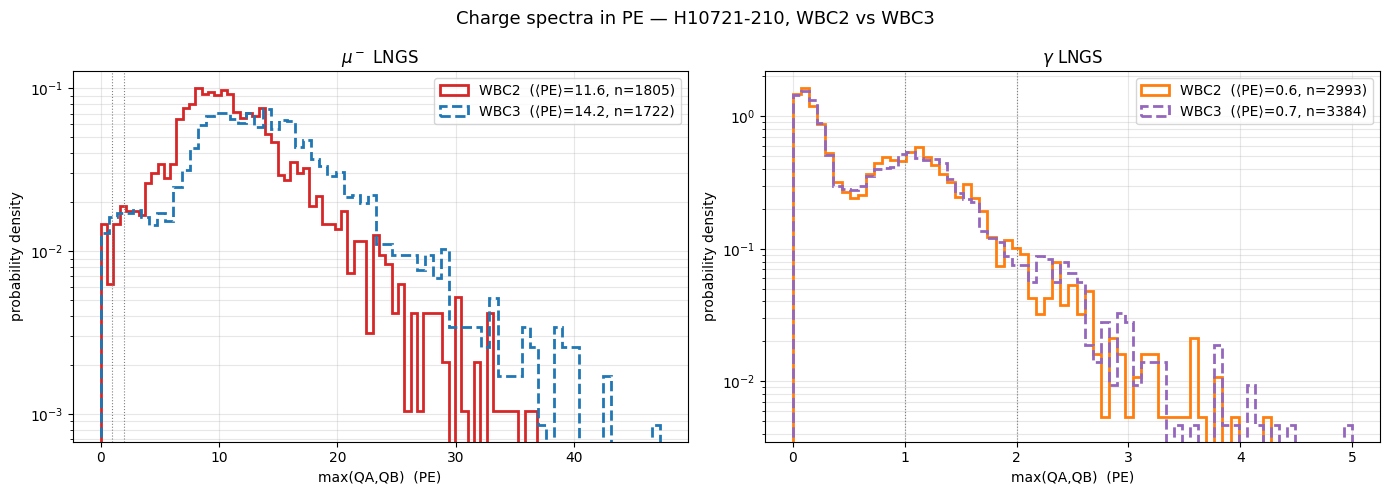

In [88]:
# ============================================================
# SPETTRI DI CARICA (PE) — WBC2 vs WBC3, muoni e gamma
# ============================================================
fig, (axm, axg) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Charge spectra in PE — H10721-210, WBC2 vs WBC3", fontsize=13)
for ax, s, ttl in [(axm, "mu_lngs", r"$\mu^-$ LNGS"), (axg, "gamma", r"$\gamma$ LNGS")]:
    for gname, gc in GEO.items():
        pe = RESULTS_GEO[gname][s]["pe"]; n = RESULTS_GEO[gname][s]["n_hits"]
        col = gc["c_mu"] if s == "mu_lngs" else gc["c_g"]
        hi  = np.percentile(pe, 99.5)
        ax.hist(pe, bins=np.linspace(0, max(hi, 5), 70), density=True, histtype="step",
                lw=2, color=col, ls=gc["ls"], label=f"{gname}  (⟨PE⟩={pe.mean():.1f}, n={n})")
    ax.set_title(ttl); ax.set_xlabel("max(QA,QB)  (PE)"); ax.set_ylabel("probability density")
    ax.set_yscale("log"); ax.legend(fontsize=10); ax.grid(True, alpha=0.3, which="both")
    for k in (1, 2): ax.axvline(k, color="gray", lw=0.8, ls=":")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "spectra_pe.pdf"), bbox_inches="tight"); plt.show()


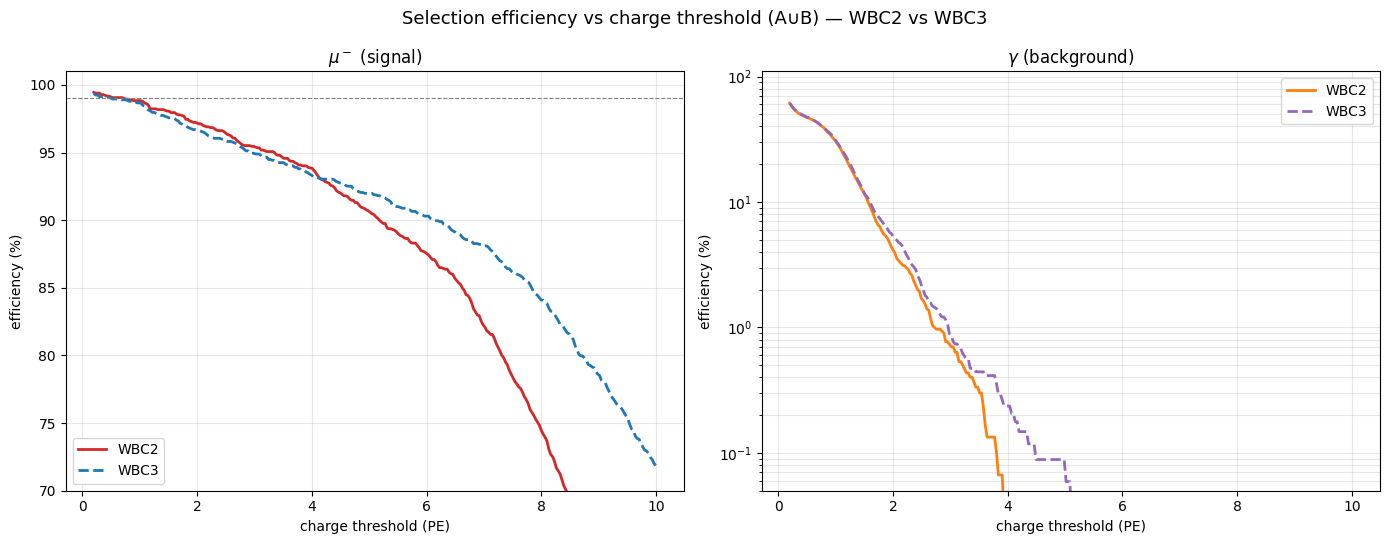

In [89]:
# ============================================================
# EFFICIENZA vs SOGLIA (PE) — logica A∪B, denominatore n_hits
#   sinistra: muoni (segnale, zoom 70-100%)   destra: gamma (fondo, log)
# ============================================================
THR = np.linspace(0.2, 10, 300)
fig, (axm, axg) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Selection efficiency vs charge threshold (A∪B) — WBC2 vs WBC3", fontsize=13)
for ax, s, ttl, lim in [(axm, "mu_lngs", r"$\mu^-$ (signal)", (70, 101)),
                        (axg, "gamma",   r"$\gamma$ (background)", None)]:
    for gname, gc in GEO.items():
        pe = RESULTS_GEO[gname][s]["pe"]; n = RESULTS_GEO[gname][s]["n_hits"]
        col = gc["c_mu"] if s == "mu_lngs" else gc["c_g"]
        ax.plot(THR, [100*(pe > t).sum()/n for t in THR], color=col, ls=gc["ls"], lw=2, label=gname)
    ax.set_title(ttl); ax.set_xlabel("charge threshold (PE)"); ax.set_ylabel("efficiency (%)")
    if lim:
        ax.set_ylim(*lim); ax.axhline(99, color="gray", lw=0.8, ls="--")
    else:
        ax.set_yscale("log"); ax.set_ylim(0.05, 110)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "eff_vs_threshold.pdf"), bbox_inches="tight"); plt.show()


In [90]:
# ============================================================
# SELEZIONE VETO — tabella efficienze, WBC2 vs WBC3
#   ε_parete = ratio_geom × ε_sel ;  ε_box = 1-(1-ε_parete)² (2 pareti)
# ============================================================
A_GEN_M2   = 6.5*6.5                 # piano generazione muoni (m²)
A_SH_PROTO = 0.385                   # area d'ombra prototipo (m²) [dalla validazione]

SELS = [
    ("A∪B > 1 PE",        lambda a, b: (a > 1) | (b > 1)),
    ("A∩B > 1 PE",        lambda a, b: (a > 1) & (b > 1)),
    ("A∩B > 2 PE",        lambda a, b: (a > 2) & (b > 2)),
    ("(A∩B>1)∨(>4 PE)",   lambda a, b: ((a > 1) & (b > 1)) | (a > 4) | (b > 4)),
]

def eff(gname, s, fn):
    r = RESULTS_GEO[gname][s]
    return fn(r["a"], r["b"]).sum() / r["n_hits"]

print(f"{'selezione':18} | {'ε_μ WBC2':>9} {'ε_μ WBC3':>9} | {'ε_γ WBC2':>9} {'ε_γ WBC3':>9} | "
      f"{'ε_box WBC2':>10} {'ε_box WBC3':>10}")
print("-"*92)
for lbl, fn in SELS:
    em = {g: 100*eff(g, "mu_lngs", fn) for g in GEO}
    eg = {g: 100*eff(g, "gamma",   fn) for g in GEO}
    # efficienza per attraversamento parete e per box (2 pareti)
    box = {}
    for g in GEO:
        r = RESULTS_GEO[g]["mu_lngs"]
        ratio = min(1.0, (r["n_hits"]/r["n_gen"]*A_GEN_M2)/A_SH_PROTO)
        ew = ratio * em[g]/100.0
        box[g] = 100*(1-(1-ew)**2)
    print(f"{lbl:18} | {em['WBC2']:>8.1f}% {em['WBC3']:>8.1f}% | "
          f"{eg['WBC2']:>8.2f}% {eg['WBC3']:>8.2f}% | {box['WBC2']:>9.3f}% {box['WBC3']:>9.3f}%")
print("-"*92)
print("ε_box = prob. di taggare un muone che attraversa il box (2 pareti).")
print("Nota: piu' luce (WBC3) NON alza ε_μ (gia' satura) ma alza leggermente il fondo γ.")


selezione          |  ε_μ WBC2  ε_μ WBC3 |  ε_γ WBC2  ε_γ WBC3 | ε_box WBC2 ε_box WBC3
--------------------------------------------------------------------------------------------
A∪B > 1 PE         |     98.8%     98.7% |    30.67%    31.03% |    99.986%    99.926%
A∩B > 1 PE         |     94.1%     93.6% |     2.04%     2.51% |    99.655%    99.399%
A∩B > 2 PE         |     87.6%     89.1% |     0.10%     0.12% |    98.474%    98.521%
(A∩B>1)∨(>4 PE)    |     96.5%     95.1% |     2.07%     2.69% |    99.874%    99.615%
--------------------------------------------------------------------------------------------
ε_box = prob. di taggare un muone che attraversa il box (2 pareti).
Nota: piu' luce (WBC3) NON alza ε_μ (gia' satura) ma alza leggermente il fondo γ.


In [91]:
# ============================================================
# RATE FISICHE — prototipo ed esperimento finale (box 3.5×3.5×1.5 m³, foro Ø1.5 m)
#   μ: flusso Mei & Hime + distribuzione zenitale MACRO (area d'ombra)
#   γ: flusso Hall A misurato (arXiv:1101.5298), φ=0.35 cm⁻²s⁻¹ (<3 MeV)
# ============================================================
SEC_DAY = 86400.0
PHI_MU_CM2 = 3.0e-8                    # cm⁻²s⁻¹ (Mei & Hime)
RATE_MU_GEN = PHI_MU_CM2 * (650.0**2) # Hz muoni sul piano 6.5×6.5 m
PHI_G_CM2   = 0.35                     # cm⁻²s⁻¹ gamma Hall A (0.3–0.4)
A_G_PROTO   = 2*(130*130)+4*(130*30)  # cm², superficie sorgente γ prototipo
RATE_G_PROTO_HZ = PHI_G_CM2/4.0 * A_G_PROTO   # ≈ 4.3 kHz (campo isotropo)

# --- box finale ---
BOX=(3.5,3.5,1.5); HOLE_D=1.5
_th=np.array([0,.0873,.1745,.2618,.3491,.4363,.5236,.6109,.6981,.7854,.8727,.9599,1.0472,1.1345])
_w =np.array([3500,3300,3000,2800,2500,2200,1800,1500,1300,1100,900,700,500,150.])
_tg=np.linspace(0,_th[-1],2000); _wg=np.interp(_tg,_th,_w); _wg/=_wg.sum()
_rng=np.random.default_rng(7); _N=2_000_000
_ts=_rng.choice(_tg,size=_N,p=_wg); _ps=_rng.uniform(0,2*np.pi,_N)
def _shadow(lx,ly,h):
    return float(np.mean(lx*ly + np.tan(_ts)*(np.abs(np.cos(_ps))*ly*h+np.abs(np.sin(_ps))*lx*h)))
A_sh_box = _shadow(BOX[0],BOX[1],BOX[2])          # facce 3.5×3.5 orizzontali
R_mu_box_day = PHI_MU_CM2*1e4 * A_sh_box * SEC_DAY
A_box = 2*BOX[0]*BOX[1]+2*BOX[0]*BOX[2]+2*BOX[1]*BOX[2] - np.pi*(HOLE_D/2)**2
A_proto = 2*(0.98*0.36+0.98*0.12+0.36*0.12)
R_g_box_hz = RATE_G_PROTO_HZ * A_box/A_proto      # scala di superficie
A_GEN_M2=6.5*6.5; A_SH_PROTO=0.385

print(f"μ box: {R_mu_box_day:.0f} attraversamenti/giorno   |   γ box: {R_g_box_hz:.0f} Hz")
print(f"(γ ∝ φ={PHI_G_CM2} cm⁻²s⁻¹; superficie box {A_box:.1f} m²)\n")

# --- selezioni veto tarate a un FAKE RATE gamma bersaglio ---
TARGET_FAKE_HZ = 0.5           # <-- fissa qui il fondo gamma residuo (Hz sul box)
TAU_MS = [0.2, 1.0, 2.0]; R_LD_HZ = 5.0; SEC_YR = 3.156e7
F_HOLE = (np.pi*(HOLE_D/2)**2) / (BOX[0]*BOX[1])     # foro: μ che escono -> 1 parete

FAMILIES = {
    "radiale  √(Q²)":  (lambda a,b,t: (a**2+b**2) > t**2,  np.linspace(1.0, 6.0, 500)),  # t = raggio (PE)
    "somma   A+B":     (lambda a,b,t: (a+b) > t,           np.linspace(1.0, 10.0, 500)), # t = soglia (PE)
}
_unit = {"radiale  √(Q²)":"PE (raggio)", "somma   A+B":"PE"}

def _fake_hz(g, fn):
    rg=RESULTS_GEO[g]["gamma"]
    return R_g_box_hz * int(fn(rg["a"],rg["b"]).sum()) / rg["n_gen"]

def _tune(g, fam, grid):
    """soglia che porta il fake rate gamma a TARGET_FAKE_HZ."""
    best=None
    for t in grid:
        rf=_fake_hz(g, lambda a,b,t=t: fam(a,b,t))
        d=abs(rf-TARGET_FAKE_HZ)
        if best is None or d<best[0]: best=(d,t,rf)
    return best[1], best[2]

# tara le soglie per geometria
TUNED={}
for fname,(fam,grid) in FAMILIES.items():
    for g in GEO:
        thr,fake=_tune(g,fam,grid)
        TUNED[(fname,g)]={"fn":(lambda a,b,fam=fam,thr=thr: fam(a,b,thr)),"thr":thr,"fake":fake}

print(f"Selezioni veto tarate a R_fake = {TARGET_FAKE_HZ} Hz sul box  (rate LD CUPID = {R_LD_HZ} Hz)")
print(f"f_hole = {100*F_HOLE:.1f}% dei μ esce dal foro -> 1 sola parete")
hdr=(f"{'selezione':16} {'geo':5} | {'soglia':>12} | {'ε_box%':>7} | {'R_μtag/d':>8} | {'R_γ(Hz)':>8} | "
     + " | ".join(f"τ={t}ms dt%,ev/yr" for t in TAU_MS))
print(hdr); print("-"*len(hdr))
for fname,(fam,grid) in FAMILIES.items():
    for g in GEO:
        T=TUNED[(fname,g)]; fn=T["fn"]
        rm=RESULTS_GEO[g]["mu_lngs"]; rg=RESULTS_GEO[g]["gamma"]
        ratio=min(1.0,(rm["n_hits"]/rm["n_gen"]*A_GEN_M2)/A_SH_PROTO)
        ew=ratio*fn(rm["a"],rm["b"]).sum()/rm["n_hits"]
        ebox=(1-F_HOLE)*(1-(1-ew)**2)+F_HOLE*ew
        Rmu_tag=R_mu_box_day*ebox; Rg=T["fake"]; Rtot=Rg+Rmu_tag/SEC_DAY
        cols=[f"{100*Rtot*t*1e-3:>6.3f}% {R_LD_HZ*Rtot*t*1e-3*SEC_YR:>8.0f}" for t in TAU_MS]
        print(f"{fname if g=='WBC2' else '':16} {g:5} | {T['thr']:>6.2f} {_unit[fname]:>5} | "
              f"{100*ebox:>6.2f}% | {Rmu_tag:>8.1f} | {Rg:>7.2f} | " + " | ".join(cols))
    print("-"*len(hdr))
print(f"Soglie tarate per geometria -> stesso R_fake ({TARGET_FAKE_HZ} Hz) -> il confronto isola ε_box.")
print("ε_box con correzione foro; dt = (γ fake + μ veri) × τ. Abbassa TARGET_FAKE_HZ per meno deadtime.")

μ box: 398 attraversamenti/giorno   |   γ box: 184030 Hz
(γ ∝ φ=0.35 cm⁻²s⁻¹; superficie box 43.7 m²)

Selezioni veto tarate a R_fake = 0.5 Hz sul box  (rate LD CUPID = 5.0 Hz)
f_hole = 14.4% dei μ esce dal foro -> 1 sola parete
selezione        geo   |       soglia |  ε_box% | R_μtag/d |  R_γ(Hz) | τ=0.2ms dt%,ev/yr | τ=1.0ms dt%,ev/yr | τ=2.0ms dt%,ev/yr
---------------------------------------------------------------------------------------------------------------------------------
radiale  √(Q²)   WBC2  |   3.95 PE (raggio) |  98.95% |    394.2 |    0.55 |  0.011%    17568 |  0.056%    87840 |  0.111%   175679
                 WBC3  |   4.56 PE (raggio) |  98.30% |    391.6 |    0.55 |  0.011%    17567 |  0.056%    87835 |  0.111%   175670
---------------------------------------------------------------------------------------------------------------------------------
somma   A+B      WBC2  |   5.18    PE |  98.94% |    394.2 |    0.55 |  0.011%    17568 |  0.056%    87840 |  0.111% 

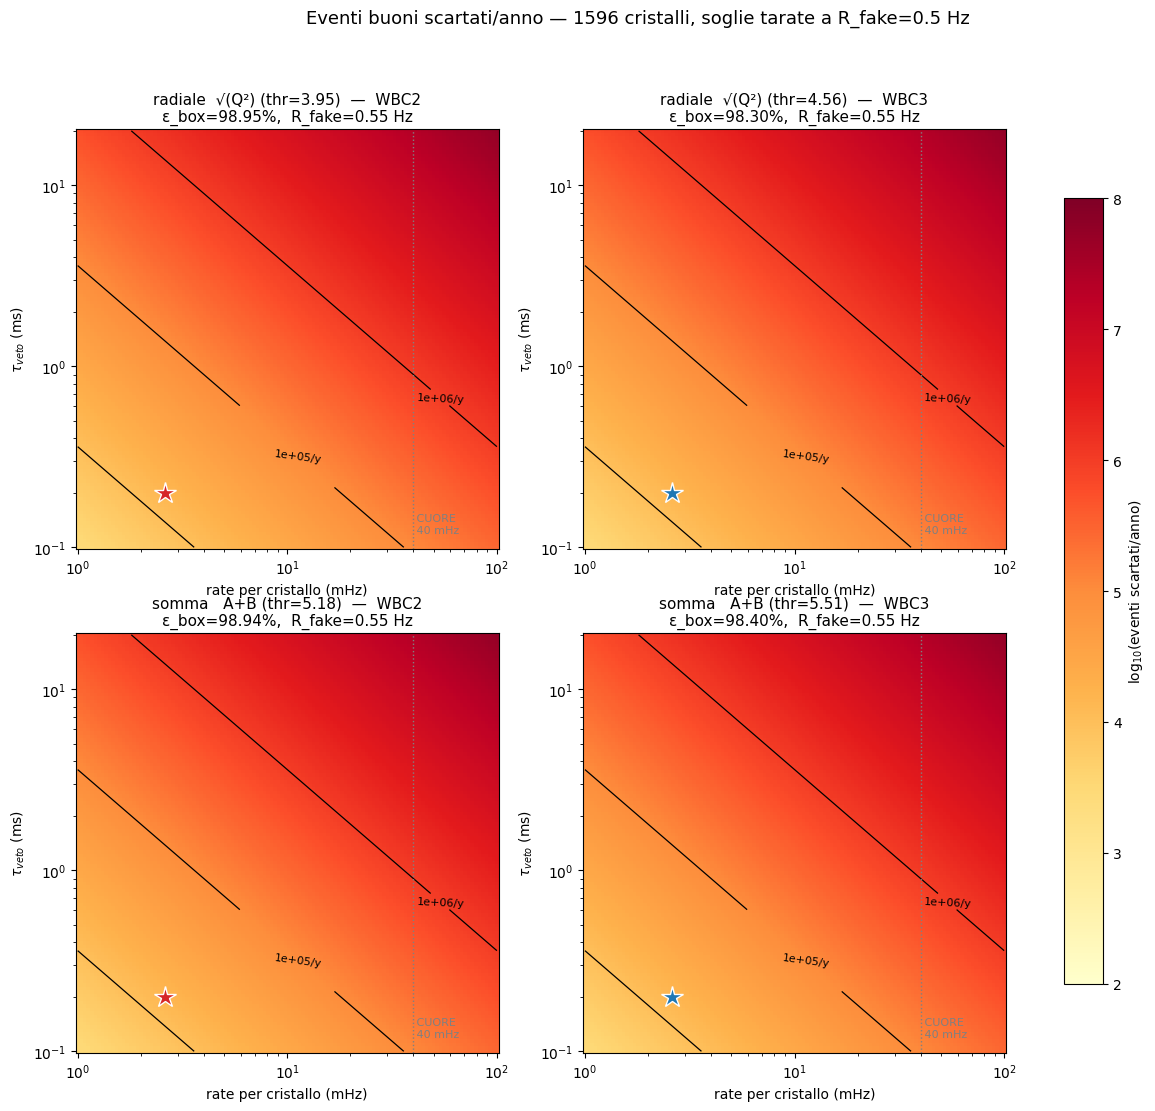

In [92]:
# ============================================================
# MAPPA 2D — eventi spuri/anno vs (rate cristalli, τ_veto)
#   Griglia 2×2: righe = selezione (radiale, somma), colonne = geometria.
#   Soglie tarate a TARGET_FAKE_HZ (dalla cella 5). ε_box e soglia nel titolo.
#   ★ = ipotesi CUPID (2.6 mHz/cristallo, τ=0.2 ms).
# ============================================================
N_CRY=1596; SEC_YR=3.156e7
R_CR=np.logspace(0,2,120); TAU=np.logspace(-1,1.3,120)
TAUg,RCRg=np.meshgrid(TAU,R_CR,indexing="ij")
A_GEN_M2=6.5*6.5; A_SH_PROTO=0.385
_fam_names=list(FAMILIES.keys())

fig,axes=plt.subplots(2,2,figsize=(15,12))
fig.suptitle(f"Eventi buoni scartati/anno — {N_CRY} cristalli, soglie tarate a R_fake={TARGET_FAKE_HZ} Hz",
             fontsize=13)
pc=None
for r,fname in enumerate(_fam_names):
    for c,g in enumerate(("WBC2","WBC3")):
        ax=axes[r][c]; gc=GEO[g]; T=TUNED[(fname,g)]; fn=T["fn"]
        rm=RESULTS_GEO[g]["mu_lngs"]
        ratio=min(1.0,(rm["n_hits"]/rm["n_gen"]*A_GEN_M2)/A_SH_PROTO)
        ew=ratio*fn(rm["a"],rm["b"]).sum()/rm["n_hits"]
        ebox=(1-F_HOLE)*(1-(1-ew)**2)+F_HOLE*ew
        rfake=T["fake"]
        N=(RCRg*1e-3*N_CRY)*rfake*(TAUg*1e-3)*SEC_YR
        pc=ax.pcolormesh(RCRg,TAUg,np.log10(N),cmap="YlOrRd",vmin=2,vmax=8,shading="auto")
        cs=ax.contour(RCRg,TAUg,N,levels=[1e2,1e3,1e4,1e5,1e6],colors="k",linewidths=0.9)
        ax.clabel(cs,fmt=lambda v:f"{v:.0e}/y",fontsize=8)
        ax.plot(2.6,0.2,"*",ms=16,color=gc["c_mu"],markeredgecolor="white")
        ax.axvline(40,color="gray",lw=1,ls=":"); ax.text(40,0.12," CUORE\n 40 mHz",fontsize=8,color="gray")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("rate per cristallo (mHz)"); ax.set_ylabel(r"$\tau_{veto}$ (ms)")
        ax.set_title(f"{fname} (thr={T['thr']:.2f})  —  {g}\n"
                     f"ε_box={100*ebox:.2f}%,  R_fake={rfake:.2f} Hz",fontsize=11)
plt.colorbar(pc,ax=axes,shrink=0.85,label=r"log$_{10}$(eventi scartati/anno)")
fig.savefig(os.path.join(OUTPUT_DIR,"decision_2D_map.pdf"),bbox_inches="tight"); plt.show()


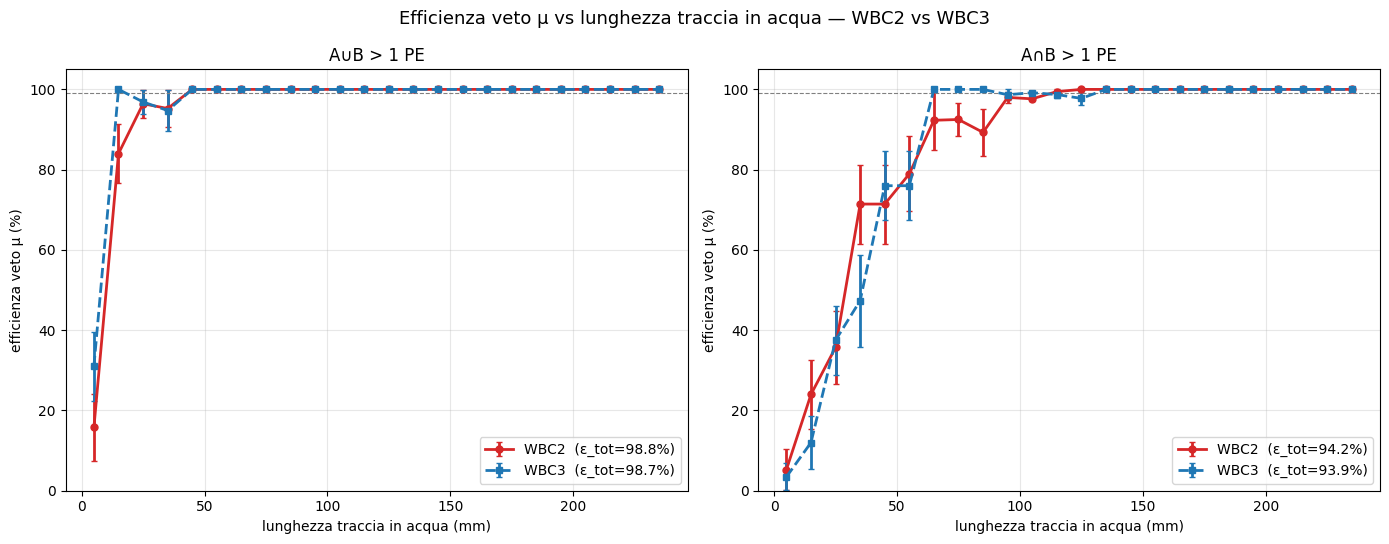

EFFICIENZA VETO μ (denom = muoni che attraversano l'acqua)
selezione    |            tutti L        |    radenti L<50mm   
             | geo        ε%    persi |      n       ε%
------------------------------------------------------------------
A∪B > 1 PE   | WBC2   98.78%       22 |    114    80.7%
             | WBC3   98.72%       22 |    130    83.1%
------------------------------------------------------------------
A∩B > 1 PE   | WBC2   94.16%      105 |    114    41.2%
             | WBC3   93.87%      105 |    130    33.8%
------------------------------------------------------------------
Nota: WBC2 e WBC3 sono campioni MC di muoni DIVERSI (run indipendenti):
le differenze <~1 punto% sono entro la statistica, NON un effetto di geometria.


In [93]:
# ============================================================
# MUONI PERSI DAI TAGLI — WBC2 vs WBC3, dipendenza dalla selezione
#   Denominatore = muoni che ATTRAVERSANO l'acqua (TrackL_water > 0),
#   inclusi quelli con 0 fotoni al PMT. Un muone e' "taggato" se supera
#   la selezione, altrimenti PERSO (leakage nel ROI di CUPID).
#   Confronto A∪B (veto-ottimale) vs A∩B (reietta gamma) e vs lung. traccia.
# ============================================================
SELS_MU = [("A∪B > 1 PE", lambda a, b: (a > 1) | (b > 1)),   # massima eff. muone
           ("A∩B > 1 PE", lambda a, b: (a > 1) & (b > 1))]   # working point anti-gamma
Lbins = np.linspace(0, 250, 26); Lc = 0.5*(Lbins[:-1]+Lbins[1:])

# --- muoni che attraversano l'acqua, con carica per canale allineata ---
mu = {}
for g, gc in GEO.items():
    with uproot.open(os.path.join(DATA_DIR, f"sim_{gc['tag']}_mu_lngs_X0mm_Y0mm_Th0deg.root")) as fh:
        trackl = fh["Eventi"]["TrackL_water_mm"].array(library="np")
        eid = fh["Fotoni"]["EventID"].array(library="np")
    uev = np.sort(np.unique(eid)).astype(int)
    a = RESULTS_GEO[g]["mu_lngs"]["a"]; b = RESULTS_GEO[g]["mu_lngs"]["b"]
    af = np.zeros(len(trackl)); bf = np.zeros(len(trackl)); af[uev] = a; bf[uev] = b
    cross = trackl > 0
    mu[g] = {"L": trackl[cross], "a": af[cross], "b": bf[cross], "n": int(cross.sum())}

# --- plot: ε_veto vs lunghezza traccia, un pannello per selezione ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Efficienza veto μ vs lunghezza traccia in acqua — WBC2 vs WBC3", fontsize=13)
for ax, (sname, fn) in zip(axes, SELS_MU):
    for g, gc in GEO.items():
        L = mu[g]["L"]; tg = fn(mu[g]["a"], mu[g]["b"])
        num,_ = np.histogram(L[tg], bins=Lbins); den,_ = np.histogram(L, bins=Lbins)
        nz = den > 0
        eff = np.full(len(den), np.nan); err = np.zeros(len(den))
        p = num[nz]/den[nz]
        eff[nz] = 100*p
        err[nz] = 100*np.sqrt(np.clip(p*(1-p),0,None)/den[nz])
        ax.errorbar(Lc, eff, yerr=err, marker=gc["mk"], color=gc["c_mu"], ls=gc["ls"], lw=2,
                    capsize=2, ms=5, label=f"{g}  (ε_tot={100*tg.sum()/mu[g]['n']:.1f}%)")
    ax.set_title(sname); ax.set_xlabel("lunghezza traccia in acqua (mm)")
    ax.set_ylabel("efficienza veto μ (%)"); ax.set_ylim(0, 105)
    ax.axhline(99, color="gray", lw=0.8, ls="--"); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "muon_veto_eff_vs_tracklength.pdf"), bbox_inches="tight"); plt.show()

# --- tabella: efficienza integrale e sui muoni radenti (L<50mm) ---
print("EFFICIENZA VETO μ (denom = muoni che attraversano l'acqua)")
print(f"{'selezione':12} | {'':4} {'tutti L':^20} | {'radenti L<50mm':^20}")
print(f"{'':12} | {'geo':4} {'ε%':>8} {'persi':>8} | {'n':>6} {'ε%':>8}")
print("-"*66)
for sname, fn in SELS_MU:
    for g in GEO:
        L=mu[g]["L"]; tg=fn(mu[g]["a"],mu[g]["b"]); m=L<50
        print(f"{sname if g=='WBC2' else '':12} | {g:4} {100*tg.sum()/len(L):>7.2f}% "
              f"{len(L)-int(tg.sum()):>8} | {int(m.sum()):>6} {100*fn(mu[g]['a'][m],mu[g]['b'][m]).sum()/max(m.sum(),1):>7.1f}%")
    print("-"*66)
print("Nota: WBC2 e WBC3 sono campioni MC di muoni DIVERSI (run indipendenti):")
print("le differenze <~1 punto% sono entro la statistica, NON un effetto di geometria.")


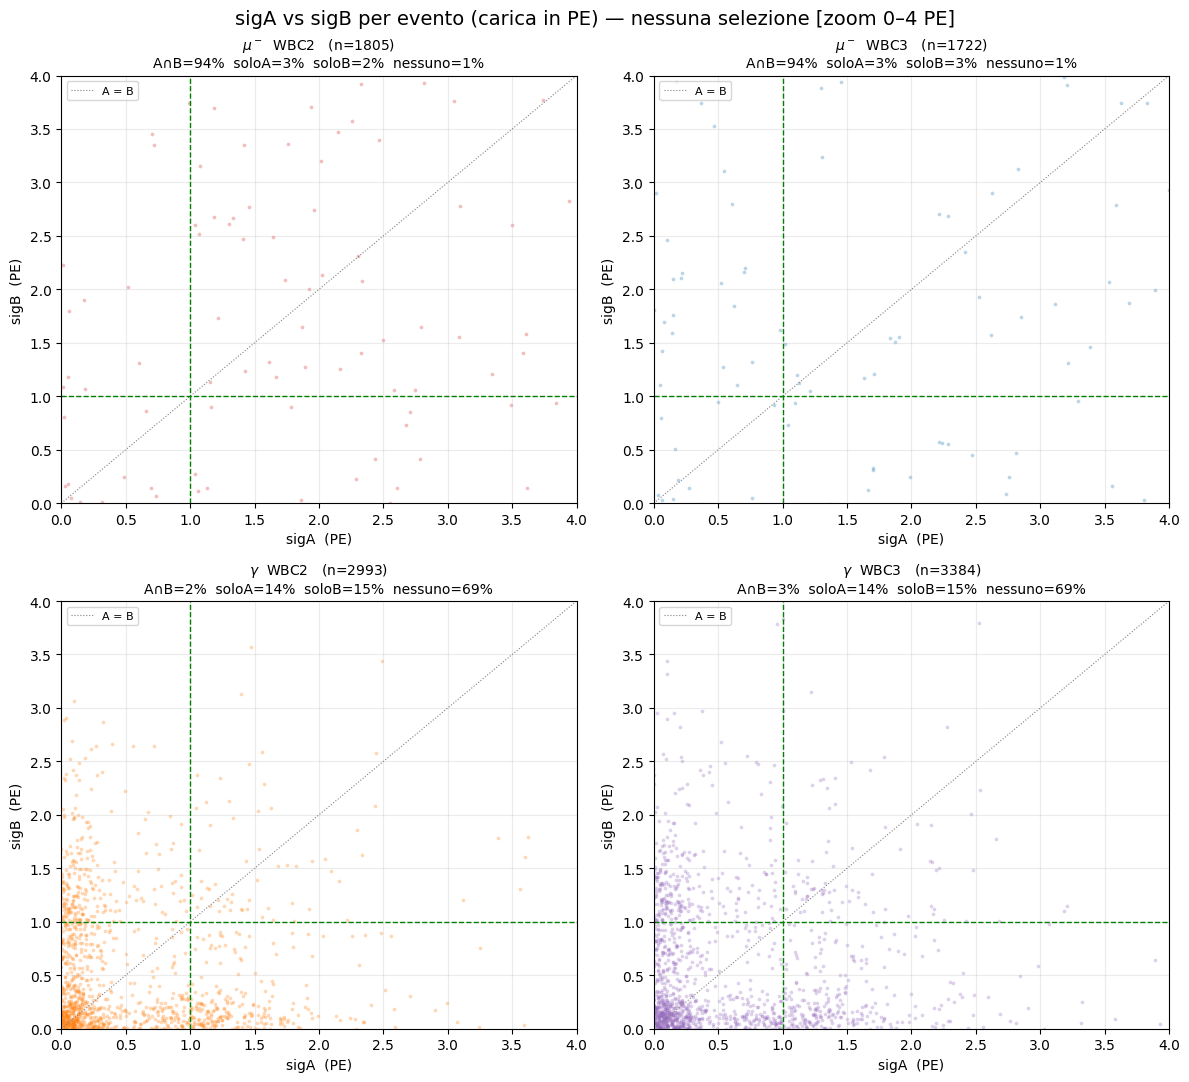

Linea verde = soglia 1 PE. Punti in alto-dx = A∩B (entrambi). Punti negli
altri quadranti = un solo canale sopra soglia: persi da A∩B, tenuti da A∪B.


In [94]:
# ============================================================
# SCATTER sigA vs sigB — NESSUNA SELEZIONE
#   Carica per canale (PE) evento per evento. 2x2: (μ, γ) × (WBC2, WBC3).
#   Mostra la correlazione tra i due PMT: i punti FUORI dal quadrante
#   in alto a destra (a>1 AND b>1) sono i muoni che A∩B perde ma A∪B tiene.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle("sigA vs sigB per evento (carica in PE) — nessuna selezione [zoom 0–4 PE]", fontsize=14)

for row, src in enumerate(("mu_lngs", "gamma")):
    for col, g in enumerate(("WBC2", "WBC3")):
        ax = axes[row][col]
        r = RESULTS_GEO[g][src]
        a = r["a"]; b = r["b"]
        col_pt = GEO[g]["c_mu"] if src == "mu_lngs" else GEO[g]["c_g"]
        ax.scatter(a, b, s=7, alpha=0.30, color=col_pt, linewidths=0)
        AXMAX = 4.0   # stessa scala per muoni e gamma (zoom sulla regione di soglia)
        ax.plot([0, AXMAX], [0, AXMAX], color="gray", lw=0.8, ls=":", label="A = B")
        ax.axvline(1, color="green", lw=1.0, ls="--"); ax.axhline(1, color="green", lw=1.0, ls="--")
        ax.set_xlim(0, AXMAX); ax.set_ylim(0, AXMAX)
        ax.set_xlabel("sigA  (PE)"); ax.set_ylabel("sigB  (PE)")
        lbl = (r"$\mu^-$" if src == "mu_lngs" else r"$\gamma$")
        # frazioni nei quadranti rispetto a soglia 1 PE
        n = r["n_hits"]
        both = ((r["a"] > 1) & (r["b"] > 1)).sum()
        onlyA = ((r["a"] > 1) & (r["b"] <= 1)).sum()
        onlyB = ((r["a"] <= 1) & (r["b"] > 1)).sum()
        none  = n - both - onlyA - onlyB
        ax.set_title(f"{lbl}  {g}   (n={n})\n"
                     f"A∩B={100*both/n:.0f}%  soloA={100*onlyA/n:.0f}%  "
                     f"soloB={100*onlyB/n:.0f}%  nessuno={100*none/n:.0f}%", fontsize=10)
        ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.25, which="both")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "scatter_sigA_sigB_no_selection.pdf"), bbox_inches="tight")
plt.show()
print("Linea verde = soglia 1 PE. Punti in alto-dx = A∩B (entrambi). Punti negli")
print("altri quadranti = un solo canale sopra soglia: persi da A∩B, tenuti da A∪B.")


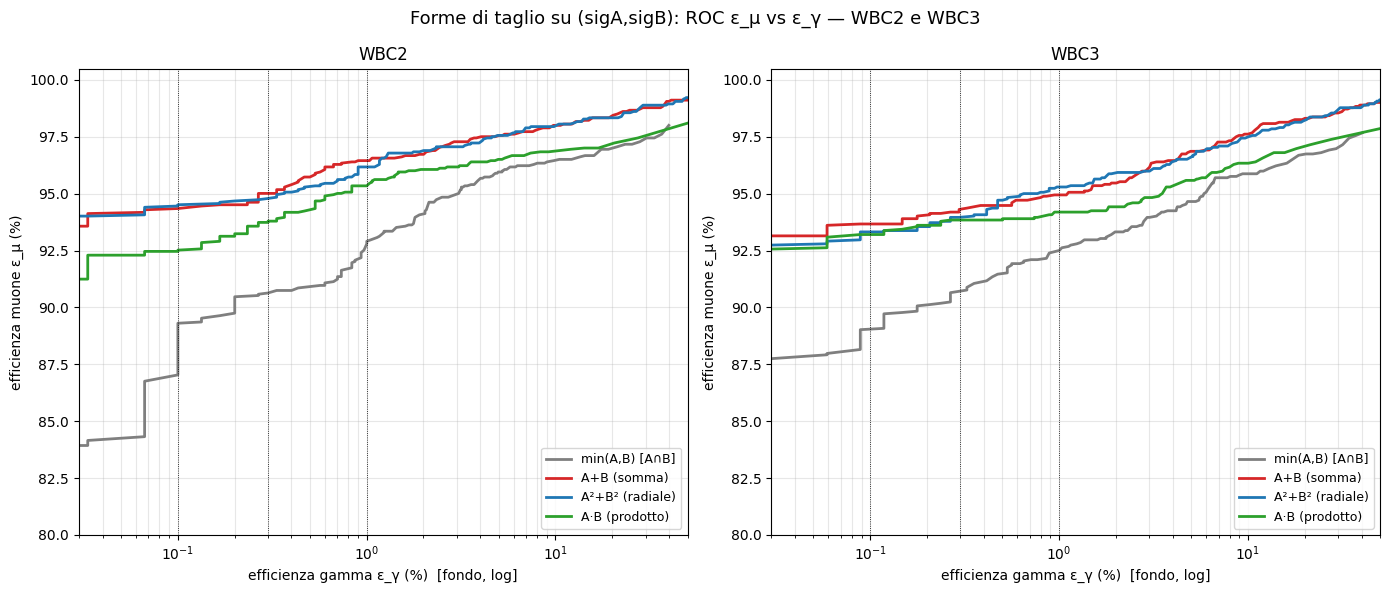

EFFICIENZA MUONE al livello di reiezione gamma richiesto (denom = n_hits)
geo   taglio            | ε_μ@ε_γ=1% | ε_μ@ε_γ=0.3% | ε_μ@ε_γ=0.1%
----------------------------------------------------------------------
WBC2  min(A,B) [A∩B]    |      92.5% |      90.6% |      86.8%
WBC2  A+B (somma)       |      96.5% |      95.0% |      94.3%
WBC2  A²+B² (radiale)   |      96.2% |      94.7% |      94.4%
WBC2  A·B (prodotto)    |      95.3% |      93.7% |      92.5%
----------------------------------------------------------------------
WBC3  min(A,B) [A∩B]    |      92.4% |      90.7% |      89.0%
WBC3  A+B (somma)       |      94.9% |      94.3% |      93.7%
WBC3  A²+B² (radiale)   |      95.3% |      94.0% |      93.3%
WBC3  A·B (prodotto)    |      94.2% |      93.8% |      93.2%
----------------------------------------------------------------------

SOGLIE corrispondenti (valore di taglio su f(A,B)) al livello ε_γ=0.1%
geo   taglio            |   soglia      unita
------------------------

In [95]:
# ============================================================
# CONFRONTO FORME DI TAGLIO su (sigA, sigB) — per geometria
#   Famiglie: min(A,B) [A∩B], A+B (somma), A²+B² (radiale), A·B (prodotto).
#   Un muone/gamma e' "taggato" se f(A,B) > soglia. Sweep della soglia ->
#   ROC (ε_μ vs ε_γ) + tabella ε_μ ai livelli di reiezione gamma richiesti.
#   Denominatore = eventi con fotoni al PMT (n_hits). Nessuna pre-selezione.
# ============================================================
CUTS = {
    "min(A,B) [A∩B]":  (lambda a,b,t: np.minimum(a,b) > t,   np.linspace(0, 6, 400)),
    "A+B (somma)":      (lambda a,b,t: (a+b) > t,             np.linspace(0, 12, 400)),
    "A²+B² (radiale)":  (lambda a,b,t: (a**2+b**2) > t**2,    np.linspace(0, 8, 400)),
    "A·B (prodotto)":   (lambda a,b,t: (a*b) > t,             np.linspace(0, 16, 400)),
}
CUT_COL = {"min(A,B) [A∩B]":"#7f7f7f", "A+B (somma)":"#d62728",
           "A²+B² (radiale)":"#1f77b4", "A·B (prodotto)":"#2ca02c"}
TARGETS = [0.01, 0.003, 0.001]     # livelli di reiezione gamma (ε_γ)

def _roc(rm, rg, fn, sw):
    em = np.array([fn(rm["a"], rm["b"], t).mean() for t in sw])
    eg = np.array([fn(rg["a"], rg["b"], t).mean() for t in sw])
    return em, eg

# --- ROC per geometria ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Forme di taglio su (sigA,sigB): ROC ε_μ vs ε_γ — WBC2 e WBC3", fontsize=13)
roc_store = {}
for ax, g in zip(axes, ("WBC2", "WBC3")):
    rm = RESULTS_GEO[g]["mu_lngs"]; rg = RESULTS_GEO[g]["gamma"]
    for name, (fn, sw) in CUTS.items():
        em, eg = _roc(rm, rg, fn, sw); roc_store[(g,name)] = (em, eg, sw)
        ax.plot(100*eg, 100*em, "-", color=CUT_COL[name], lw=2, label=name)
    ax.set_xscale("log"); ax.set_xlim(0.03, 50); ax.set_ylim(80, 100.5)
    ax.set_xlabel("efficienza gamma ε_γ (%)  [fondo, log]")
    ax.set_ylabel("efficienza muone ε_μ (%)")
    ax.set_title(g); ax.grid(True, alpha=0.3, which="both"); ax.legend(fontsize=9, loc="lower right")
    for tgt in TARGETS: ax.axvline(100*tgt, color="k", lw=0.6, ls=":")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "cut_shapes_roc.pdf"), bbox_inches="tight"); plt.show()

# --- tabella: ε_μ ai livelli di reiezione gamma, per geometria ---
def _eff_mu_at(g, name, target):
    em, eg, sw = roc_store[(g,name)]
    ok = np.where(eg <= target)[0]
    if len(ok)==0: return np.nan, np.nan
    k = ok[0]; return 100*em[k], sw[k]     # (ε_μ %, soglia)

print("EFFICIENZA MUONE al livello di reiezione gamma richiesto (denom = n_hits)")
print(f"{'geo':5} {'taglio':17} | " + " | ".join(f"ε_μ@ε_γ={100*t:g}%" for t in TARGETS))
print("-"*70)
for g in ("WBC2","WBC3"):
    for name in CUTS:
        vals = [ _eff_mu_at(g,name,t)[0] for t in TARGETS ]
        cells = " | ".join(f"{v:>9.1f}%" if np.isfinite(v) else f"{'--':>10}" for v in vals)
        print(f"{g:5} {name:17} | {cells}")
    print("-"*70)

# --- tabella soglie corrispondenti (valori ottenuti) ---
print("\nSOGLIE corrispondenti (valore di taglio su f(A,B)) al livello ε_γ=0.1%")
print(f"{'geo':5} {'taglio':17} | {'soglia':>8} {'unita':>10}")
print("-"*44)
_units = {"min(A,B) [A∩B]":"PE","A+B (somma)":"PE","A²+B² (radiale)":"PE (raggio)","A·B (prodotto)":"PE²"}
for g in ("WBC2","WBC3"):
    for name in CUTS:
        _, thr = _eff_mu_at(g, name, 0.001)
        print(f"{g:5} {name:17} | {thr:>8.2f} {_units[name]:>10}" if np.isfinite(thr) else f"{g:5} {name:17} |     --")
    print("-"*44)


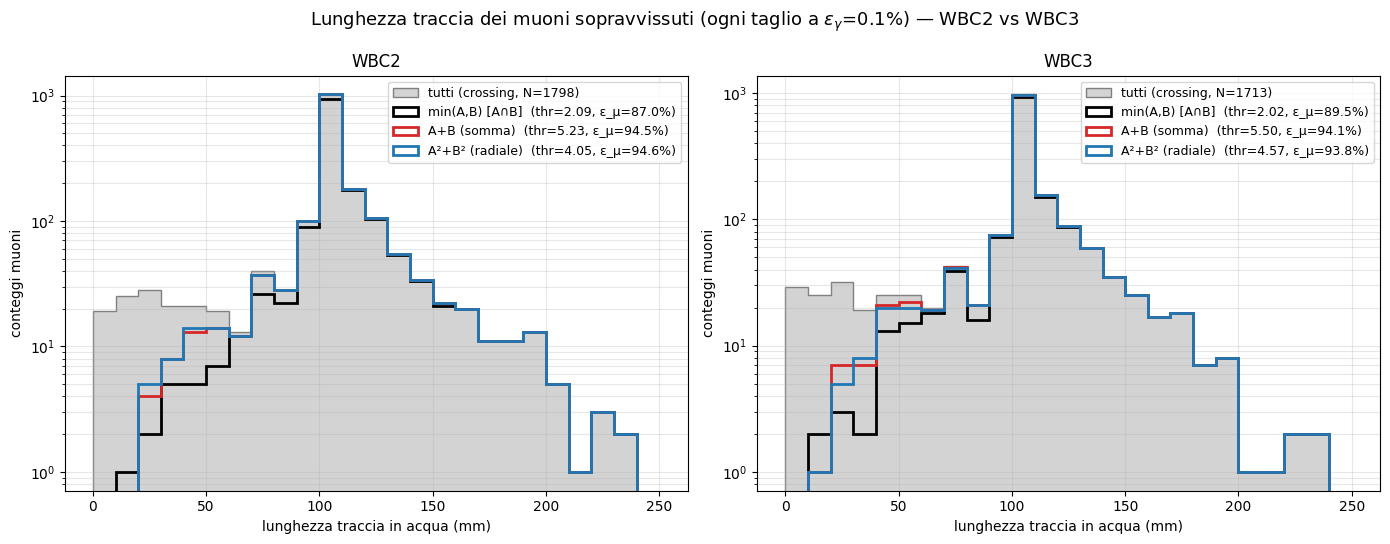

Muoni sopravvissuti per regione di traccia (ε_γ=0.1%)
geo   taglio            | ε corti (L<50) | ε lunghi (L≥50) |   ε tot
--------------------------------------------------------------
WBC2  min(A,B) [A∩B]    |          11.4% |           92.2% |   87.0%
WBC2  A+B (somma)       |          21.9% |           99.4% |   94.5%
WBC2  A²+B² (radiale)   |          23.7% |           99.4% |   94.6%
--------------------------------------------------------------
WBC3  min(A,B) [A∩B]    |          15.4% |           95.6% |   89.5%
WBC3  A+B (somma)       |          27.7% |           99.6% |   94.1%
WBC3  A²+B² (radiale)   |          26.2% |           99.3% |   93.8%
--------------------------------------------------------------


In [96]:
# ============================================================
# LUNGHEZZA TRACCIA dei muoni SOPRAVVISSUTI a 3 selezioni — WBC2 vs WBC3
#   Selezioni (ognuna tarata a ε_γ = 0.1%): min(A,B) [A∩B], A+B, A²+B².
#   Denominatore = muoni che attraversano l'acqua (TrackL > 0).
#   Mostra quali tagli perdono i muoni a traccia corta (radenti).
# ============================================================
SELS3 = {
    "min(A,B) [A∩B]": (lambda a,b,t: np.minimum(a,b) > t,  np.linspace(0,6,400),  "black"),
    "A+B (somma)":     (lambda a,b,t: (a+b) > t,            np.linspace(0,12,400), "#d62728"),
    "A²+B² (radiale)": (lambda a,b,t: (a**2+b**2) > t**2,   np.linspace(0,8,400),  "#1f77b4"),
}
GAMMA_TARGET = 0.001                       # ε_γ = 0.1%
Lbins = np.linspace(0, 250, 26)

def _thr_for_gamma(rg, fn, sw, target):
    for t in sw:
        if fn(rg["a"], rg["b"], t).mean() <= target: return t
    return sw[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(rf"Lunghezza traccia dei muoni sopravvissuti (ogni taglio a $\epsilon_\gamma$={100*GAMMA_TARGET:g}%) — WBC2 vs WBC3",
             fontsize=13)
for ax, g in zip(axes, ("WBC2", "WBC3")):
    gc = GEO[g]
    with uproot.open(os.path.join(DATA_DIR, f"sim_{gc['tag']}_mu_lngs_X0mm_Y0mm_Th0deg.root")) as fh:
        trackl = fh["Eventi"]["TrackL_water_mm"].array(library="np")
        eid = fh["Fotoni"]["EventID"].array(library="np")
    uev = np.sort(np.unique(eid)).astype(int)
    a = RESULTS_GEO[g]["mu_lngs"]["a"]; b = RESULTS_GEO[g]["mu_lngs"]["b"]
    af = np.zeros(len(trackl)); bf = np.zeros(len(trackl)); af[uev]=a; bf[uev]=b
    cross = trackl > 0
    L = trackl[cross]; ac = af[cross]; bc = bf[cross]
    rg = RESULTS_GEO[g]["gamma"]

    # riferimento: tutti i muoni che attraversano
    ax.hist(L, bins=Lbins, histtype="stepfilled", color="lightgray", edgecolor="gray",
            lw=1.0, label=f"tutti (crossing, N={len(L)})")
    for name,(fn,sw,col) in SELS3.items():
        thr = _thr_for_gamma(rg, fn, sw, GAMMA_TARGET)
        surv = fn(ac, bc, thr)
        ax.hist(L[surv], bins=Lbins, histtype="step", color=col, lw=2,
                label=f"{name}  (thr={thr:.2f}, ε_μ={100*surv.sum()/len(L):.1f}%)")
    ax.set_title(g); ax.set_xlabel("lunghezza traccia in acqua (mm)")
    ax.set_ylabel("conteggi muoni"); ax.set_yscale("log")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "tracklength_survivors_3cuts.pdf"), bbox_inches="tight"); plt.show()

# --- conteggio: muoni persi a traccia corta (L<50mm) vs lunga ---
print(f"Muoni sopravvissuti per regione di traccia (ε_γ={100*GAMMA_TARGET:g}%)")
print(f"{'geo':5} {'taglio':17} | {'ε corti (L<50)':>14} | {'ε lunghi (L≥50)':>15} | {'ε tot':>7}")
print("-"*62)
for g in ("WBC2","WBC3"):
    gc=GEO[g]
    with uproot.open(os.path.join(DATA_DIR, f"sim_{gc['tag']}_mu_lngs_X0mm_Y0mm_Th0deg.root")) as fh:
        trackl=fh["Eventi"]["TrackL_water_mm"].array(library="np")
        eid=fh["Fotoni"]["EventID"].array(library="np")
    uev=np.sort(np.unique(eid)).astype(int)
    a=RESULTS_GEO[g]["mu_lngs"]["a"]; b=RESULTS_GEO[g]["mu_lngs"]["b"]
    af=np.zeros(len(trackl)); bf=np.zeros(len(trackl)); af[uev]=a; bf[uev]=b
    cross=trackl>0; L=trackl[cross]; ac=af[cross]; bc=bf[cross]; rg=RESULTS_GEO[g]["gamma"]
    short=L<50; long=~short
    for name,(fn,sw,col) in SELS3.items():
        thr=_thr_for_gamma(rg,fn,sw,GAMMA_TARGET); surv=fn(ac,bc,thr)
        es=100*surv[short].sum()/max(short.sum(),1); el=100*surv[long].sum()/max(long.sum(),1)
        et=100*surv.sum()/len(L)
        print(f"{g:5} {name:17} | {es:>13.1f}% | {el:>14.1f}% | {et:>6.1f}%")
    print("-"*62)


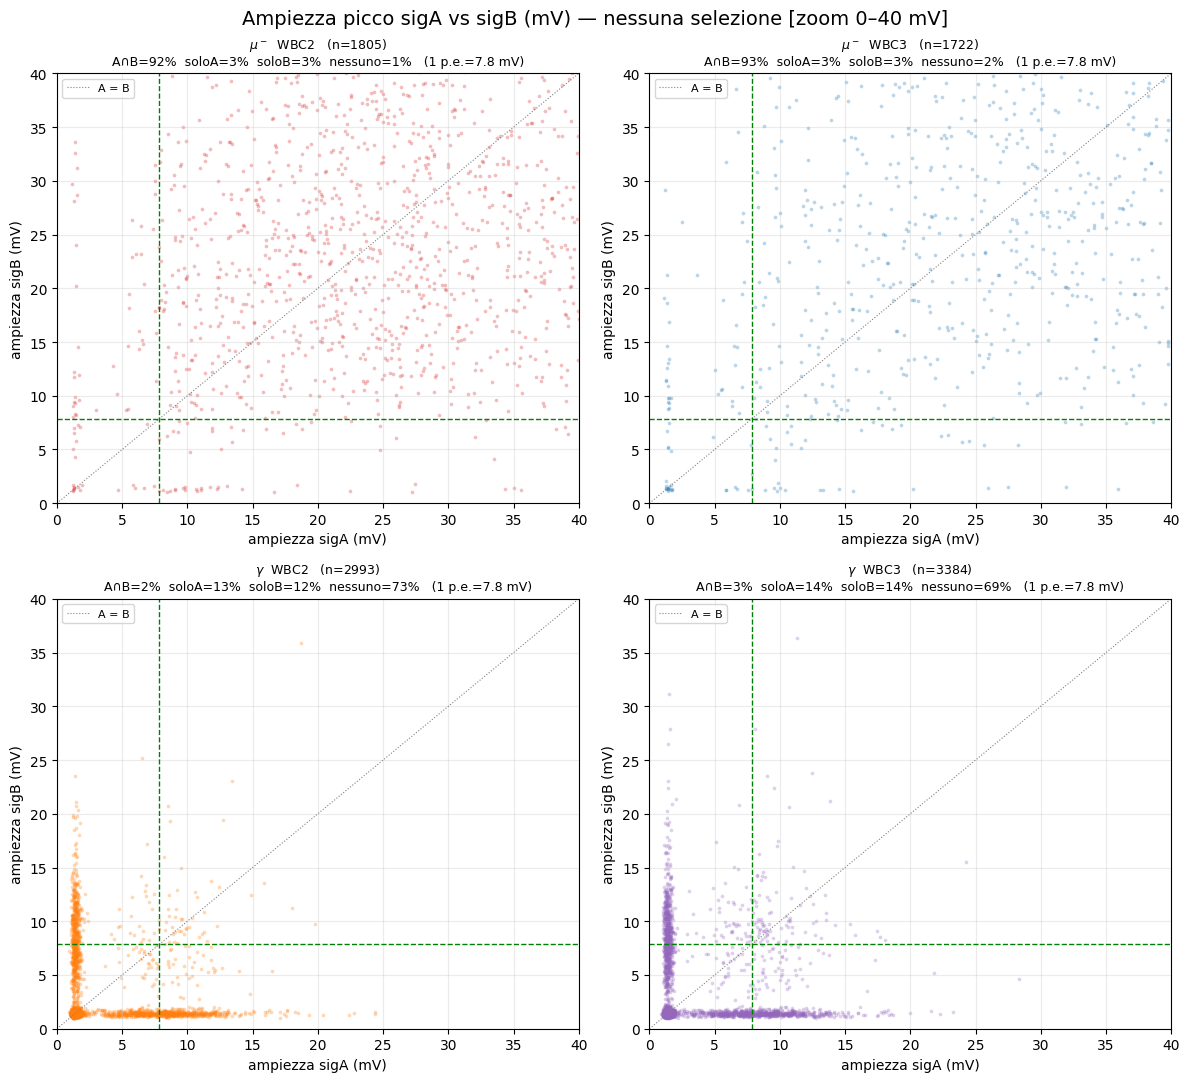

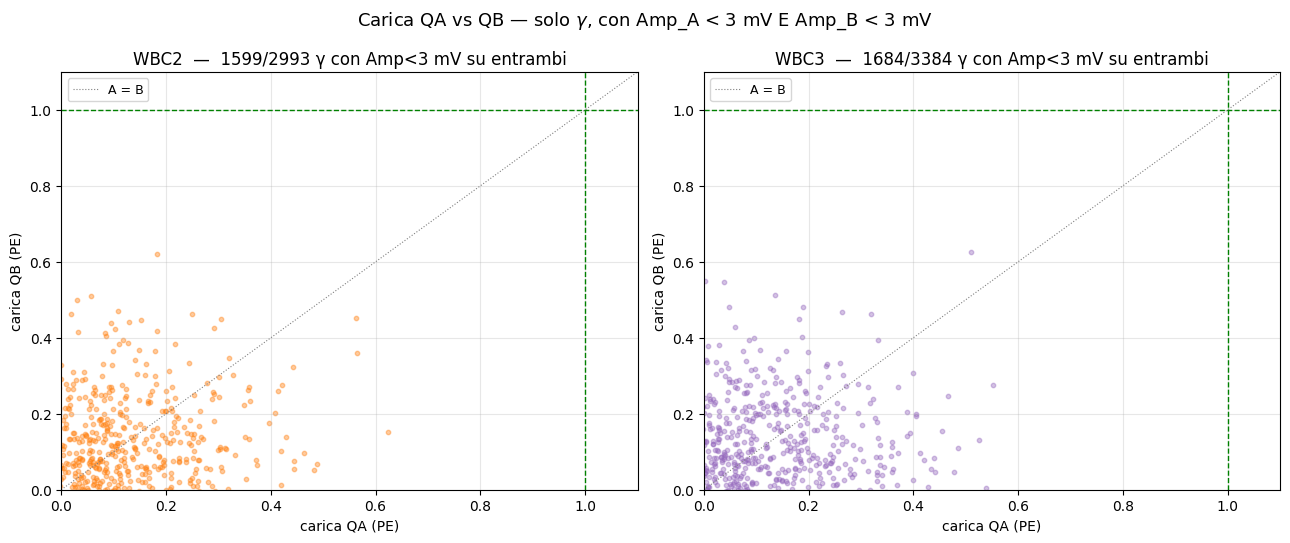

Linea verde FIG1 = 1 p.e. = 7.8 mV. FIG2: gamma con ampiezza < 3 mV su A e B.


In [97]:
# ============================================================
# SCATTER ampiezza_A vs ampiezza_B (picco, mV) — NESSUNA SELEZIONE
#   + scatter CARICA A vs B dei soli gamma con Amp_A<3 e Amp_B<3 mV.
#   Carica e ampiezza sono estratte dalla STESSA digitizzazione (stessi
#   fotoni accettati) -> filtro coerente evento per evento.
#   Richiede la cella 1 (costanti PMT: amp, sigT, TRIG, TTS, get_qe, ...).
# ============================================================
_pw0 = int(130/DT); _pw1 = int(260/DT); _ptax = taxis[_pw0:_pw1]   # finestra picco
_gi0 = i0 - _pw0; _gi1 = i1 - _pw0                                 # gate [140,200] entro _ptax

def _ch_wf(ts, rng):
    """restituisce (picco |min| mV, carica PE) dalla stessa waveform."""
    noise = rng.normal(0., NOISE_ADC*LSB, len(_ptax))
    if len(ts) == 0:
        wf = noise
    else:
        g  = np.maximum(0., rng.normal(1., SPE_RES, len(ts)))
        tj = ts + TRIG + rng.normal(0., TTS, len(ts))
        dt = _ptax[:, None] - tj[None, :]
        wf = amp*(np.exp(-0.5*(dt/sigT)**2) @ g) + noise
    peak = -wf.min()                                    # ampiezza (mV)
    q    = -np.trapezoid(wf[_gi0:_gi1])/LSB/qSPE        # carica (PE)
    return peak, q

def load_pk_q(tag, src, rng):
    with uproot.open(os.path.join(DATA_DIR, f"sim_{tag}_{src}_X0mm_Y0mm_Th0deg.root")) as fh:
        a = fh["Fotoni"].arrays(["EventID","Arrival_Time_ns","PMT_ID","E_Hit_eV"], library="np")
    eid=a["EventID"]; t=a["Arrival_Time_ns"]; pid=a["PMT_ID"]
    acc = rng.random(len(eid)) < get_qe(1240.0/a["E_Hit_eV"])
    order=np.argsort(eid,kind="stable")
    eid_s,t_s,pid_s,acc_s = eid[order],t[order],pid[order],acc[order]
    uev,starts=np.unique(eid_s,return_index=True); bounds=np.append(starts,len(eid_s))
    pa=np.empty(len(uev)); pb=np.empty(len(uev)); qa=np.empty(len(uev)); qb=np.empty(len(uev))
    for k in range(len(uev)):
        sl=slice(bounds[k],bounds[k+1]); p=pid_s[sl]; tt=t_s[sl]; aa=acc_s[sl]
        pa[k],qa[k]=_ch_wf(tt[(p==0)&aa], rng); pb[k],qb[k]=_ch_wf(tt[(p==1)&aa], rng)
    return {"pa":pa,"pb":pb,"qa":qa,"qb":qb}

_rng_pk=np.random.default_rng(11)
PK={(g,s): load_pk_q(GEO[g]["tag"], s, _rng_pk) for g in GEO for s in ("mu_lngs","gamma")}

# ---- FIG 1: ampiezza picco A vs B (mV), 2x2 ----
AMP1 = abs(amp); AXMAX = 40.0        # 1 p.e. (mV) e scala comune (regolabile)
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle(f"Ampiezza picco sigA vs sigB (mV) — nessuna selezione [zoom 0–{AXMAX:.0f} mV]", fontsize=14)
for row, s in enumerate(("mu_lngs","gamma")):
    for col, g in enumerate(("WBC2","WBC3")):
        ax=axes[row][col]; pa=PK[(g,s)]["pa"]; pb=PK[(g,s)]["pb"]
        cpt=GEO[g]["c_mu"] if s=="mu_lngs" else GEO[g]["c_g"]
        ax.scatter(pa,pb,s=7,alpha=0.30,color=cpt,linewidths=0)
        ax.plot([0,AXMAX],[0,AXMAX],color="gray",lw=0.8,ls=":",label="A = B")
        ax.axvline(AMP1,color="green",lw=1.0,ls="--"); ax.axhline(AMP1,color="green",lw=1.0,ls="--")
        ax.set_xlim(0,AXMAX); ax.set_ylim(0,AXMAX)
        ax.set_xlabel("ampiezza sigA (mV)"); ax.set_ylabel("ampiezza sigB (mV)")
        lbl=r"$\mu^-$" if s=="mu_lngs" else r"$\gamma$"; n=len(pa)
        both=((pa>AMP1)&(pb>AMP1)).sum(); oA=((pa>AMP1)&(pb<=AMP1)).sum()
        oB=((pa<=AMP1)&(pb>AMP1)).sum(); none=n-both-oA-oB
        ax.set_title(f"{lbl}  {g}   (n={n})\nA∩B={100*both/n:.0f}%  soloA={100*oA/n:.0f}%  "
                     f"soloB={100*oB/n:.0f}%  nessuno={100*none/n:.0f}%   (1 p.e.={AMP1:.1f} mV)", fontsize=9)
        ax.legend(fontsize=8,loc="upper left"); ax.grid(True,alpha=0.25)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,"scatter_ampA_ampB_no_selection.pdf"),bbox_inches="tight"); plt.show()

# ---- FIG 2: CARICA A vs B dei gamma con Amp_A<3 e Amp_B<3 mV ----
AMP_CUT = 3.0    # mV su entrambi i canali (regolabile)
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 5.5))
fig2.suptitle(rf"Carica QA vs QB — solo $\gamma$, con Amp_A < {AMP_CUT:.0f} mV E Amp_B < {AMP_CUT:.0f} mV", fontsize=13)
for ax, g in zip(ax2, ("WBC2","WBC3")):
    d=PK[(g,"gamma")]
    sel=(d["pa"]<AMP_CUT)&(d["pb"]<AMP_CUT)
    qa=d["qa"][sel]; qb=d["qb"][sel]
    hi=max(qa.max(), qb.max(), 1)*1.1 if sel.sum() else 1
    ax.scatter(qa,qb,s=10,alpha=0.4,color=GEO[g]["c_g"],linewidths=1)
    ax.plot([0,hi],[0,hi],color="gray",lw=0.8,ls=":",label="A = B")
    ax.axvline(1,color="green",lw=1.0,ls="--"); ax.axhline(1,color="green",lw=1.0,ls="--")
    ax.set_xlim(0,hi); ax.set_ylim(0,hi)
    ax.set_xlabel("carica QA (PE)"); ax.set_ylabel("carica QB (PE)")
    ax.set_title(f"{g}  —  {int(sel.sum())}/{len(d['pa'])} γ con Amp<{AMP_CUT:.0f} mV su entrambi")
    ax.legend(fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR,"scatter_gamma_charge_lowamp.pdf"),bbox_inches="tight"); plt.show()
print(f"Linea verde FIG1 = 1 p.e. = {AMP1:.1f} mV. FIG2: gamma con ampiezza < {AMP_CUT:.0f} mV su A e B.")


In [98]:
# ============================================================
# DEAD TIME con selezione AMPIEZZA+CARICA — pulizia gamma 2D
#   Regione GAMMA (rigettata dal tag muone):
#     Amp_A < 3 PE  AND  Amp_B < 3 PE  AND  (Q_A²+Q_B²) < 4     [circolare]
#   Variante: stessa cosa ma con (Q_A + Q_B) < S   [somma], S tarato
#   alla STESSA reiezione gamma per confronto equo.
#   TAG muone (veto) = NON nella regione gamma.
#   Richiede: cella ampiezze (PK) e cella 5 (rate box: R_mu_box_day,
#   R_g_box_hz, F_HOLE, A_GEN_M2, A_SH_PROTO, R_LD_HZ, TAU_MS, ...).
# ============================================================
assert "PK" in dir(), "Esegui prima la cella degli scatter ampiezza (definisce PK)."
assert "R_g_box_hz" in dir(), "Esegui prima la cella 5 (rate esperimento finale)."

AMP1 = abs(amp)                 # ampiezza 1 p.e. (mV)
AMP_CUT_PE = 3.0                # soglia ampiezza per canale (PE)
R2_CIRC   = 4.0                 # Q_A²+Q_B² < 4  (raggio 2 PE)

def _tag_circ(d):
    aA=d["pa"]/AMP1; aB=d["pb"]/AMP1
    gamma_reg=(aA<AMP_CUT_PE)&(aB<AMP_CUT_PE)&((d["qa"]**2+d["qb"]**2)<R2_CIRC)
    return ~gamma_reg
def _tag_sum(d, S):
    aA=d["pa"]/AMP1; aB=d["pb"]/AMP1
    gamma_reg=(aA<AMP_CUT_PE)&(aB<AMP_CUT_PE)&((d["qa"]+d["qb"])<S)
    return ~gamma_reg

# --- fake fraction gamma (media geometrie) per il circolare ---
def _gfake(tagfn):
    return np.mean([1-tagfn(PK[(g,"gamma")]).mean() for g in GEO])  # frazione rigettata... no
# vogliamo la frazione TAGGATA (fake): tag.sum()/n_hits
def _gamma_tag_frac(tagfn):
    return np.mean([tagfn(PK[(g,"gamma")]).mean() for g in GEO])
gfrac_circ = _gamma_tag_frac(_tag_circ)
# tara S della somma per eguagliare la fake fraction del circolare
S_grid = np.linspace(0.5, 6.0, 200)
S_sum = S_grid[np.argmin([abs(_gamma_tag_frac(lambda d,S=S:_tag_sum(d,S))-gfrac_circ) for S in S_grid])]
print(f"Reiezione gamma circolare: fake gamma tag = {100*gfrac_circ:.3f}%")
print(f"Soglia somma equivalente: Q_A+Q_B < {S_sum:.2f} PE  (stessa fake fraction)\n")

SELS = [("circolare  Q²<4",      _tag_circ),
        (f"somma  QA+QB<{S_sum:.2f}", lambda d: _tag_sum(d, S_sum))]

TAU_MS=[0.2,1.0,2.0]
hdr=(f"{'selezione':18} {'geo':5} | {'ε_box%':>7} | {'R_μtag/d':>8} | {'R_γ(Hz)':>8} | "
     + " | ".join(f"τ={t}ms dt%,ev/yr" for t in TAU_MS))
print(hdr); print("-"*len(hdr))
for sname, tagfn in SELS:
    for g in GEO:
        dm=PK[(g,"mu_lngs")]; dg=PK[(g,"gamma")]
        n_hits_m=len(dm["pa"]); n_gen_m=RESULTS_GEO[g]["mu_lngs"]["n_gen"]
        n_hits_g=len(dg["pa"]); n_gen_g=RESULTS_GEO[g]["gamma"]["n_gen"]
        ratio=min(1.0,(n_hits_m/n_gen_m*A_GEN_M2)/A_SH_PROTO)
        ew=ratio*tagfn(dm).sum()/n_hits_m
        ebox=(1-F_HOLE)*(1-(1-ew)**2)+F_HOLE*ew
        ng=int(tagfn(dg).sum())
        Rmu_tag=R_mu_box_day*ebox
        Rg=R_g_box_hz*ng/n_gen_g                       # fake gamma (Hz)
        Rtot=Rg+Rmu_tag/SEC_DAY
        cols=[]
        for t in TAU_MS:
            dt=Rtot*t*1e-3; cols.append(f"{100*dt:>6.3f}% {R_LD_HZ*dt*SEC_YR:>8.0f}")
        lim="<" if ng==0 else " "
        print(f"{sname if g=='WBC2' else '':18} {g:5} | {100*ebox:>6.2f}% | {Rmu_tag:>8.1f} | "
              f"{lim}{Rg:>7.2f} | " + " | ".join(cols))
    print("-"*len(hdr))
print("TAG muone = NON(Amp_A<3PE ∧ Amp_B<3PE ∧ pulizia-carica). ε_box con correzione foro.")
print("Le due selezioni hanno la STESSA reiezione gamma -> confronto isola ε_μ (=ε_box).")


Reiezione gamma circolare: fake gamma tag = 5.712%
Soglia somma equivalente: Q_A+Q_B < 2.24 PE  (stessa fake fraction)

selezione          geo   |  ε_box% | R_μtag/d |  R_γ(Hz) | τ=0.2ms dt%,ev/yr | τ=1.0ms dt%,ev/yr | τ=2.0ms dt%,ev/yr
--------------------------------------------------------------------------------------------------------------------
circolare  Q²<4    WBC2  |  99.57% |    396.7 |    27.60 |  0.552%   871341 |  2.761%  4356706 |  5.522%  8713413
                   WBC3  |  99.17% |    395.1 |    39.93 |  0.799%  1260475 |  3.994%  6302375 |  7.988% 12604751
--------------------------------------------------------------------------------------------------------------------
somma  QA+QB<2.24  WBC2  |  99.57% |    396.7 |    25.40 |  0.508%   801646 |  2.540%  4008228 |  5.080%  8016456
                   WBC3  |  99.19% |    395.2 |    41.59 |  0.832%  1312747 |  4.160%  6563735 |  8.319% 13127469
-------------------------------------------------------------------------